# 03 — Optimizers & Training: SGD → Adam → BatchNorm → Dropout
**Phase 3 · Week 9 · Wednesday**

## What We Cover Today
| Topic | Core Idea |
|---|---|
| SGD | Vanilla gradient descent — update = −η·gradient |
| Momentum | Accumulate velocity to push through flat regions and narrow valleys |
| Adam | Adaptive per-parameter learning rates using first and second moment estimates |
| LR Schedulers | Decrease learning rate on a schedule for fine-tuned convergence |
| BatchNorm | Normalise each layer's input across a batch — stabilises and accelerates training |
| Dropout | Randomly zero activations to prevent co-adaptation (regularisation) |
| Weight Init | He vs Xavier vs random — matters for gradient flow at initialisation |

---

## 1 · SGD and Momentum

### Vanilla SGD
```
θ ← θ − η · ∇L(θ)
```
Problem: oscillates in narrow valleys, slow through flat regions.

### SGD + Momentum
```
v ← μ·v + ∇L(θ)       (accumulate velocity, μ typically 0.9)
θ ← θ − η·v
```
Momentum smooths oscillations and builds speed in consistent directions.

### SGD + Nesterov Momentum
```
v ← μ·v + ∇L(θ − μ·v)   ← look ahead before computing gradient
θ ← θ − η·v
```
A "lookahead" correction — slightly better convergence than standard momentum.

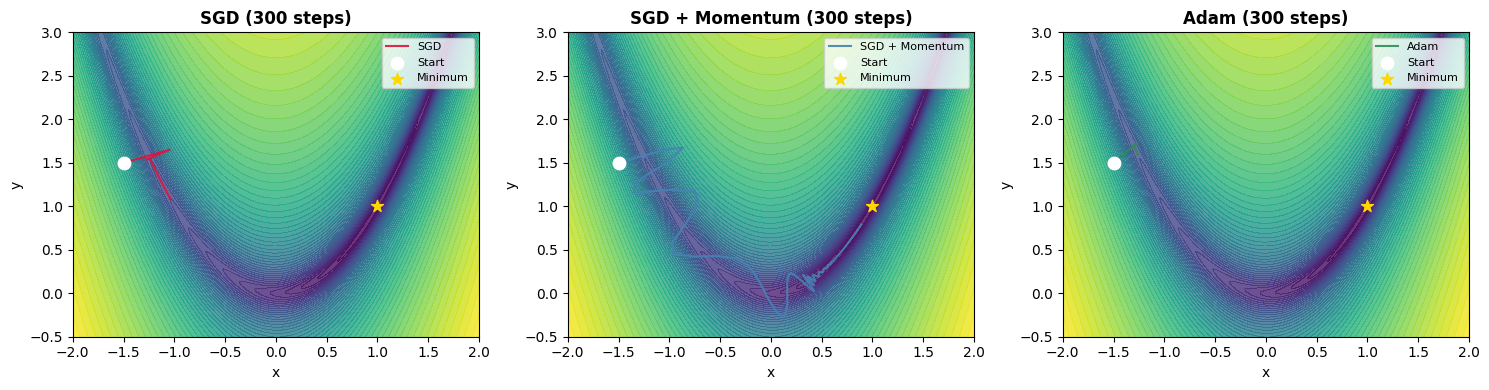

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── Visualise SGD vs Momentum on a 2D loss surface ──
# Rosenbrock function: f(x,y) = (1-x)² + 100(y-x²)²  has a narrow curved valley

def rosenbrock(x, y):
    return (1 - x)**2 + 100*(y - x**2)**2

def run_optimiser_2d(optim_name, steps=300, lr=0.001):
    x = torch.tensor([-1.5], dtype=torch.float, requires_grad=True)
    y = torch.tensor([ 1.5], dtype=torch.float, requires_grad=True)

    if optim_name == 'SGD':
        opt = optim.SGD([x, y], lr=lr)
    elif optim_name == 'Momentum':
        opt = optim.SGD([x, y], lr=lr, momentum=0.9)
    else:
        opt = optim.Adam([x, y], lr=0.01)

    path = [(x.item(), y.item())]
    for _ in range(steps):
        opt.zero_grad()
        loss = rosenbrock(x, y)
        loss.backward()
        opt.step()
        path.append((x.item(), y.item()))
    return path

sgd_path  = run_optimiser_2d('SGD',      lr=0.001)
mom_path  = run_optimiser_2d('Momentum', lr=0.001)
adam_path = run_optimiser_2d('Adam',     lr=0.01)

# Plot
xx = np.linspace(-2, 2, 300)
yy = np.linspace(-0.5, 3, 300)
X_grid, Y_grid = np.meshgrid(xx, yy)
Z_grid = (1 - X_grid)**2 + 100*(Y_grid - X_grid**2)**2

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, path, name, color in zip(axes,
    [sgd_path, mom_path, adam_path],
    ['SGD', 'SGD + Momentum', 'Adam'],
    ['crimson', 'steelblue', 'seagreen']):
    ax.contourf(X_grid, Y_grid, np.log(Z_grid + 1), levels=50, cmap='viridis', alpha=0.8)
    xs, ys = zip(*path)
    ax.plot(xs, ys, color=color, lw=1.5, alpha=0.9, label=name)
    ax.scatter(*path[0], c='white', s=80, zorder=5, label='Start')
    ax.scatter(1, 1, c='gold', s=80, marker='*', zorder=5, label='Minimum')
    ax.set_title(f"{name} ({len(path)-1} steps)", fontweight='bold')
    ax.set_xlabel("x"); ax.set_ylabel("y"); ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("optimiser_paths.png", dpi=120, bbox_inches='tight')
plt.show()

---

## 2 · Adam — Adaptive Moment Estimation

Adam keeps **running estimates of gradient mean (m) and variance (v)** per parameter:

```
mₜ = β₁·mₜ₋₁ + (1−β₁)·gₜ          ← 1st moment (mean, exponential MA)
vₜ = β₂·vₜ₋₁ + (1−β₂)·gₜ²         ← 2nd moment (variance, exponential MA)

m̂ₜ = mₜ / (1−β₁ᵗ)                  ← bias correction (important early in training)
v̂ₜ = vₜ / (1−β₂ᵗ)

θₜ = θₜ₋₁ − η · m̂ₜ / (√v̂ₜ + ε)    ← update (large grad → small step, small grad → bigger step)
```

**Default hyperparameters:** β₁=0.9, β₂=0.999, ε=1e-8, η=1e-3

**Intuition:** parameters that usually have small gradients (sparse features) get a relatively larger update; parameters with consistently large gradients get a smaller effective lr. Bias correction stops the first few steps from being tiny.

In [2]:
# Manual Adam implementation to understand it step by step
class ManualAdam:
    def __init__(self, params, lr=1e-3, betas=(0.9, 0.999), eps=1e-8):
        self.params = list(params)
        self.lr, self.b1, self.b2, self.eps = lr, *betas, eps
        self.m  = [torch.zeros_like(p) for p in self.params]
        self.v  = [torch.zeros_like(p) for p in self.params]
        self.t  = 0

    def step(self):
        self.t += 1
        for i, p in enumerate(self.params):
            if p.grad is None: continue
            g = p.grad.data
            self.m[i] = self.b1 * self.m[i] + (1 - self.b1) * g
            self.v[i] = self.b2 * self.v[i] + (1 - self.b2) * g**2
            m_hat = self.m[i] / (1 - self.b1**self.t)
            v_hat = self.v[i] / (1 - self.b2**self.t)
            p.data -= self.lr * m_hat / (v_hat.sqrt() + self.eps)

    def zero_grad(self):
        for p in self.params:
            if p.grad is not None:
                p.grad.zero_()

# Verify manual Adam matches PyTorch Adam on a simple quadratic
torch.manual_seed(0)
w_manual = torch.tensor([3.0], requires_grad=True)
w_torch  = torch.tensor([3.0], requires_grad=True)
opt_manual = ManualAdam([w_manual], lr=0.1)
opt_torch  = optim.Adam([w_torch], lr=0.1)

for step in range(30):
    # Manual
    loss_m = (w_manual**2).sum()
    opt_manual.zero_grad(); loss_m.backward(); opt_manual.step()
    # PyTorch
    loss_t = (w_torch**2).sum()
    opt_torch.zero_grad(); loss_t.backward(); opt_torch.step()

print(f"Manual Adam  final w: {w_manual.item():.6f}")
print(f"PyTorch Adam final w: {w_torch.item():.6f}")
print(f"Difference          : {abs(w_manual.item()-w_torch.item()):.2e}")
print("✓ Implementations match!" if abs(w_manual.item()-w_torch.item()) < 1e-5 else "✗ Mismatch")

Manual Adam  final w: 0.419777
PyTorch Adam final w: 0.419777
Difference          : 2.09e-07
✓ Implementations match!


---

## 3 · Learning Rate Schedulers

A fixed lr can't be optimal throughout: large early for fast progress, small later for fine-tuning.

| Scheduler | Formula | When to use |
|---|---|---|
| `StepLR(step, γ)` | lr × γ every `step` epochs | Simple, predictable |
| `MultiStepLR([30,60], γ)` | lr × γ at epoch 30, 60 | When milestones are known |
| `CosineAnnealingLR(T_max)` | lr = η_min + ½(η_max−η_min)(1+cos(πt/T)) | Smooth warmup → cooldown |
| `OneCycleLR(...)` | warmup → peak → anneal (1 cycle) | Super-convergence (fast training) |
| `ReduceLROnPlateau(patience)` | Reduce lr when val loss stops improving | When you don't know optimal schedule |

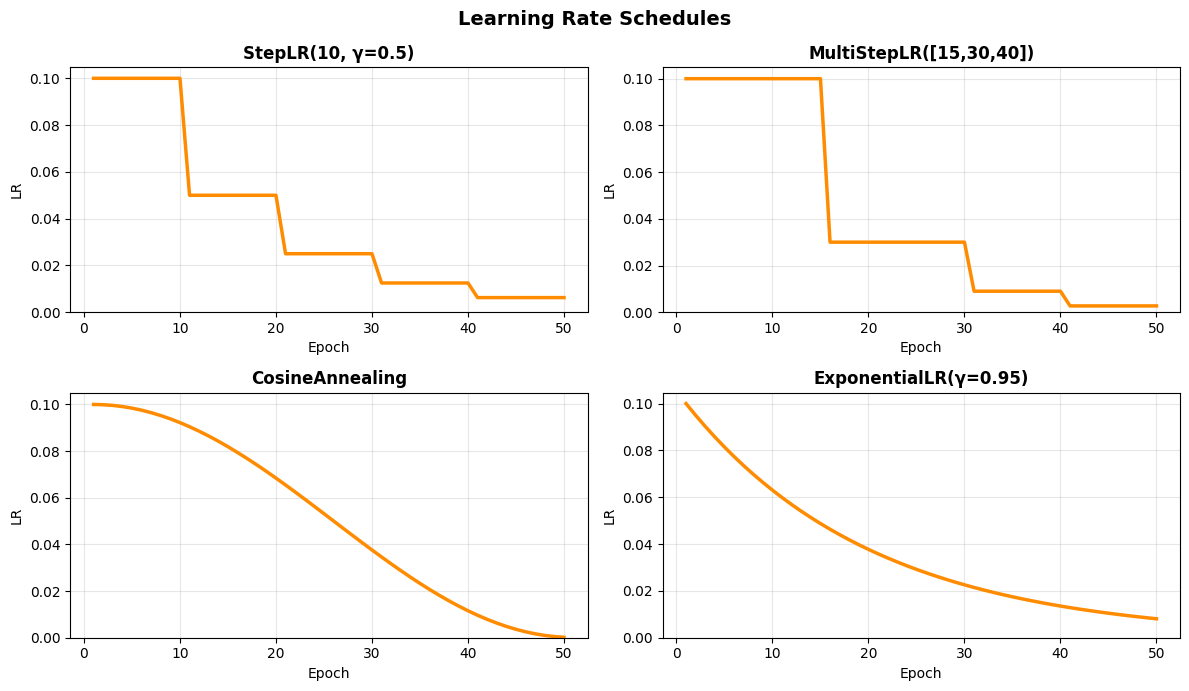

In [3]:
# Compare LR schedules visually
def get_lr_curve(scheduler_fn, n_epochs=50):
    dummy_net = nn.Linear(10, 1)
    opt = optim.SGD(dummy_net.parameters(), lr=0.1)
    sched = scheduler_fn(opt)
    lrs = []
    dummy_param = list(dummy_net.parameters())[0]
    for _ in range(n_epochs):
        lrs.append(opt.param_groups[0]['lr'])
        # dummy step so scheduler order is correct (optimizer.step -> scheduler.step)
        loss = dummy_net(torch.randn(1, 10)).sum()
        opt.zero_grad(); loss.backward(); opt.step()
        sched.step()
    return lrs

epochs = np.arange(1, 51)

schedules = {
    'StepLR(10, γ=0.5)':      lambda o: optim.lr_scheduler.StepLR(o, step_size=10, gamma=0.5),
    'MultiStepLR([15,30,40])': lambda o: optim.lr_scheduler.MultiStepLR(o, milestones=[15,30,40], gamma=0.3),
    'CosineAnnealing':         lambda o: optim.lr_scheduler.CosineAnnealingLR(o, T_max=50, eta_min=1e-4),
    'ExponentialLR(γ=0.95)':   lambda o: optim.lr_scheduler.ExponentialLR(o, gamma=0.95),
}

fig, axes = plt.subplots(2, 2, figsize=(12, 7))
fig.suptitle("Learning Rate Schedules", fontsize=14, fontweight='bold')
for ax, (name, fn) in zip(axes.flat, schedules.items()):
    lrs = get_lr_curve(fn)
    ax.plot(epochs, lrs, lw=2.5, color='darkorange')
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel("Epoch"); ax.set_ylabel("LR"); ax.set_ylim(bottom=0)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("lr_schedules.png", dpi=120, bbox_inches='tight')
plt.show()

---

## 4 · BatchNorm — Normalise Within the Network

Without BatchNorm, activations at layer k can have arbitrary scale/shift depending on earlier layers (**internal covariate shift**). This makes training slow and sensitive to lr.

**BatchNorm during training** (over a mini-batch of size B):
```
μ_B = (1/B) Σᵢ xᵢ                    ← batch mean
σ²_B = (1/B) Σᵢ (xᵢ − μ_B)²         ← batch variance
x̂ᵢ = (xᵢ − μ_B) / √(σ²_B + ε)      ← normalise
yᵢ = γ·x̂ᵢ + β                        ← scale & shift (learnable γ, β)
```

**During inference:** uses running mean/variance collected over all training batches (not the current batch).

**Why it helps:**
- Allows higher learning rates
- Reduces sensitivity to weight initialisation
- Acts as mild regulariser (each sample sees slightly different normalisation due to batch contents)

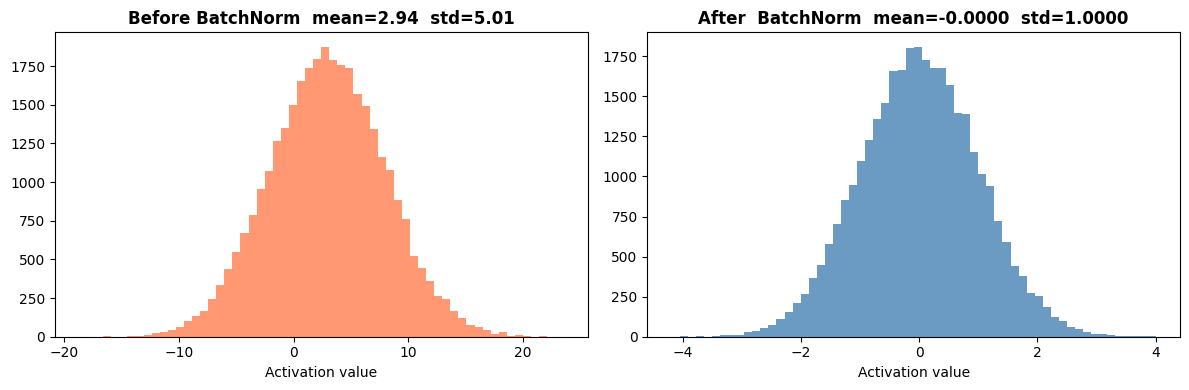

BatchNorm with batch_size=1 at eval (uses running stats): shape torch.Size([1, 64]) ✓


In [4]:
# Show the effect of BatchNorm on activation distributions
torch.manual_seed(0)
N, D = 512, 64
X_raw = torch.randn(N, D) * 5 + 3          # skewed: mean≈3, std≈5

bn = nn.BatchNorm1d(D)
X_normed = bn(X_raw)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(X_raw.detach().numpy().flatten(), bins=60, color='coral',    alpha=0.8)
axes[0].set_title(f"Before BatchNorm  mean={X_raw.mean():.2f}  std={X_raw.std():.2f}", fontweight='bold')
axes[0].set_xlabel("Activation value")

axes[1].hist(X_normed.detach().numpy().flatten(), bins=60, color='steelblue', alpha=0.8)
axes[1].set_title(f"After  BatchNorm  mean={X_normed.mean():.4f}  std={X_normed.std():.4f}", fontweight='bold')
axes[1].set_xlabel("Activation value")

plt.tight_layout()
plt.savefig("batchnorm_effect.png", dpi=120, bbox_inches='tight')
plt.show()

# Show that BN uses running stats at eval time
bn.eval()
X_single = torch.randn(1, D)   # batch of 1 — impossible without running stats
out = bn(X_single)
print(f"BatchNorm with batch_size=1 at eval (uses running stats): shape {out.shape} ✓")

---

## 5 · Dropout & Weight Initialisation

### Dropout
At each training step, randomly zero a fraction p of activations:
```
mask ~ Bernoulli(1-p)
output = activation × mask / (1-p)   ← scaled so expected value is unchanged
```
At inference: no dropout, use all activations as-is (model.eval() handles this automatically).

**Why it works:** prevents neurons from co-adapting. Forces each neuron to be useful independently — like training an ensemble of 2^n sub-networks.

### Weight Initialisation

| Method | Formula | Best for |
|---|---|---|
| **Zeros** | W = 0 | Never — kills symmetry |
| **Random Normal** | W ~ N(0, 0.01) | Shallow nets only |
| **Xavier / Glorot** | W ~ U(−√(6/(fᵢₙ+fₒᵤₜ)), +√(6/(fᵢₙ+fₒᵤₜ))) | Sigmoid / Tanh |
| **He / Kaiming** | W ~ N(0, √(2/fᵢₙ)) | ReLU (default choice) |

**Intuition:** He init keeps activation variance ≈ 1 across layers for ReLU, preventing gradients from exploding or vanishing at initialisation.

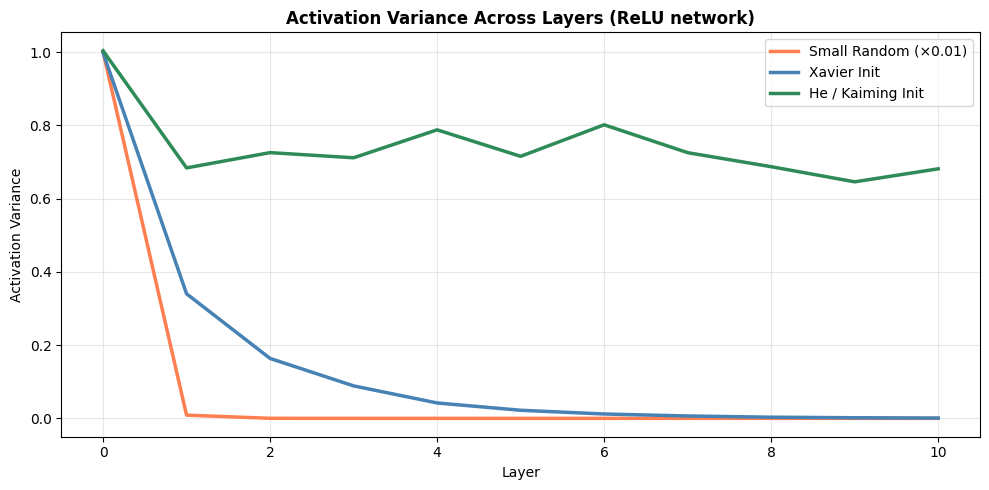

He init keeps variance near 1 — healthy gradient flow throughout all layers


In [5]:
# Visualise activation distributions for different initialisations across 10 layers
def simulate_forward(init_fn, n_layers=10, n=1000, d=256):
    x = torch.randn(n, d)
    variances = [x.var().item()]
    for _ in range(n_layers):
        w = init_fn(d, d)
        x = torch.relu(x @ w)
        variances.append(x.var().item())
    return variances

def zeros_init(fan_in, fan_out):   return torch.zeros(fan_in, fan_out)
def small_rand(fan_in, fan_out):   return torch.randn(fan_in, fan_out) * 0.01
def xavier(fan_in, fan_out):
    std = np.sqrt(2.0 / (fan_in + fan_out))
    return torch.randn(fan_in, fan_out) * std
def he(fan_in, fan_out):
    std = np.sqrt(2.0 / fan_in)
    return torch.randn(fan_in, fan_out) * std

torch.manual_seed(0)
np.random.seed(0)

configs = [('Small Random (×0.01)', small_rand, 'coral'),
           ('Xavier Init',           xavier,      'steelblue'),
           ('He / Kaiming Init',     he,          'seagreen')]

fig, ax = plt.subplots(figsize=(10, 5))
for name, fn, color in configs:
    try:
        vars_ = simulate_forward(fn)
        ax.plot(vars_, lw=2.5, label=name, color=color)
    except Exception as e:
        print(f"{name} failed: {e}")

ax.set_xlabel("Layer"); ax.set_ylabel("Activation Variance")
ax.set_title("Activation Variance Across Layers (ReLU network)", fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("weight_init_comparison.png", dpi=120, bbox_inches='tight')
plt.show()
print("He init keeps variance near 1 — healthy gradient flow throughout all layers")

---

## 6 · Full Optimizer Comparison Study

Train the same network with 4 different optimisers and compare loss curves.

Training: SGD (lr=0.01)...


  Final loss: 2.2023
Training: SGD + Momentum...


  Final loss: 0.5748
Training: SGD + Nesterov...


  Final loss: 0.5839
Training: Adam (lr=1e-3)...


  Final loss: 0.2689


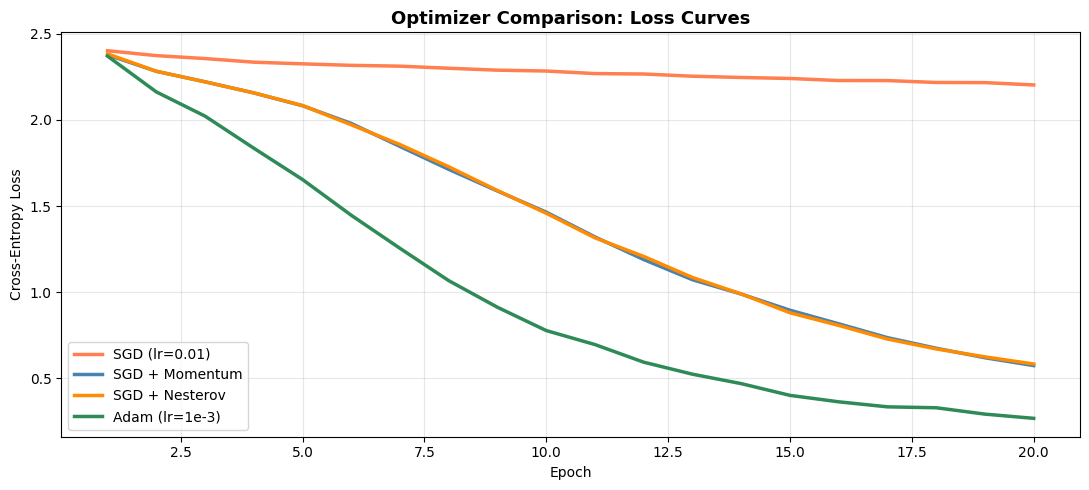

In [6]:
# Synthetic data
torch.manual_seed(0)
N = 8000
X_data = torch.randn(N, 784)
y_data = torch.randint(0, 10, (N,))
mean, std = X_data.mean(), X_data.std()
X_data = (X_data - mean) / std

ds = TensorDataset(X_data, y_data)
loader = DataLoader(ds, batch_size=256, shuffle=True)

def make_model():
    return nn.Sequential(
        nn.Linear(784, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.3),
        nn.Linear(256, 128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.3),
        nn.Linear(128, 10)
    ).to(device)

optimisers = {
    'SGD (lr=0.01)':           lambda m: optim.SGD(m.parameters(), lr=0.01),
    'SGD + Momentum':          lambda m: optim.SGD(m.parameters(), lr=0.01, momentum=0.9),
    'SGD + Nesterov':          lambda m: optim.SGD(m.parameters(), lr=0.01, momentum=0.9, nesterov=True),
    'Adam (lr=1e-3)':          lambda m: optim.Adam(m.parameters(), lr=1e-3),
}

criterion = nn.CrossEntropyLoss()
N_EPOCHS  = 20
all_curves = {}

for opt_name, opt_fn in optimisers.items():
    print(f"Training: {opt_name}...")
    model_cmp = make_model()
    optimizer = opt_fn(model_cmp)
    epoch_losses = []

    for epoch in range(N_EPOCHS):
        model_cmp.train()
        batch_losses = []
        for Xb, yb in loader:
            Xb, yb = Xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model_cmp(Xb), yb)
            loss.backward()
            optimizer.step()
            batch_losses.append(loss.item())
        epoch_losses.append(np.mean(batch_losses))

    all_curves[opt_name] = epoch_losses
    print(f"  Final loss: {epoch_losses[-1]:.4f}")

# Plot comparison
fig, ax = plt.subplots(figsize=(11, 5))
colors = ['coral', 'steelblue', 'darkorange', 'seagreen']
for (name, losses), color in zip(all_curves.items(), colors):
    ax.plot(range(1, N_EPOCHS+1), losses, lw=2.5, label=name, color=color)

ax.set_xlabel("Epoch"); ax.set_ylabel("Cross-Entropy Loss")
ax.set_title("Optimizer Comparison: Loss Curves", fontsize=13, fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("optimizer_comparison.png", dpi=120, bbox_inches='tight')
plt.show()

---

## What I Learned Today

**SGD** — Simplest optimiser: W ← W − η·∇L. Momentum adds a velocity term (μ=0.9) that accumulates in consistent directions and dampens oscillations in narrow valleys.

**Adam** — Keeps per-parameter running estimates of gradient mean (m) and variance (v). Effective lr for each parameter is η/√v̂ — large for infrequently updated params, small for frequently updated. Almost always converges faster than plain SGD.

**LR Schedulers** — CosineAnnealing and StepLR are the most common. The key idea is to let the model explore with a large lr early, then settle with a small lr late. OneCycleLR is popular for fast training (super-convergence).

**BatchNorm** — Normalises pre-activations to zero mean, unit variance across each batch, then applies learnable scale γ and shift β. Stabilises training, allows higher lr, and reduces sensitivity to weight init. Critical: use `model.eval()` at test time so BN uses running statistics.

**Dropout** — During training, randomly sets p fraction of activations to zero and scales remaining by 1/(1-p). Forces redundancy — each neuron must be independently useful. Use `model.eval()` to disable at inference.

**He initialisation** — For ReLU networks: W ~ N(0, √(2/fan_in)). Keeps activation variance ≈ 1 across layers, preventing vanishing/exploding gradients at initialisation. Xavier init (√(1/fan_in)) is better for Tanh/Sigmoid.

**Practical rule of thumb:**
```
Start with: Adam + lr=1e-3 + He init + BatchNorm + Dropout(0.3)
If training is slow: add OneCycleLR or CosineAnnealing
If overfitting: increase Dropout, add weight decay (L2): optim.Adam(..., weight_decay=1e-4)
```